Install dependencies

In [ ]:
# %pip install numpy matplotlib scikit-learn

Generate dataset

In [43]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression

# generating data
x, y = make_regression(n_samples=100, n_features=10, noise=1, random_state=42)

# Data analysis

1. plot target $`y`$ against feature $`x_5`$

Text(0, 0.5, 'y')

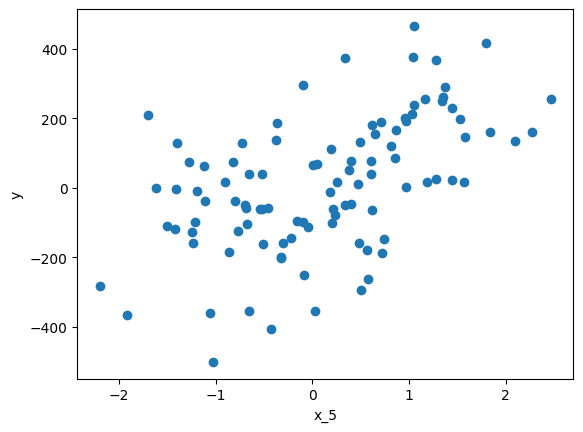

In [ ]:
plt.scatter(x[:, 5], y)
plt.xlabel("x_5")
plt.ylabel("y")

# Univariate regression

```math
\hat{y} = w*x+b
```
1. write a function `predict(w: float, x: float, b: float) -> float` that estimates target $`y`$ given feature $`x`$ and parameters $`w`$ and $`b`$ in the case of univariate linear regression
2. write a function `init_parameters() -> tuple[float, float]` that returns random values for parameters $`w`$ and $`b`$
3. apply the model for all the values of feature $`x_5`$ (compute $`\hat{y}`$)
4. add the regression line to the plot of target $`y`$ against feature $`x_5`$

In [6]:
b = -25.0
w = 100.0

def init_parameters() -> tuple[float, float]:
    """ write a function that initializes w and b to random values """
    ...
    return np.random.randn(), np.random.randn()

w, b = init_parameters()

def predict(w: float, x: float, b: float) -> float:
    """ write a function that predicts y given x, w and b in the case of univariate linear regression"""
    ...
    return w * x + b

Text(0, 0.5, 'y')

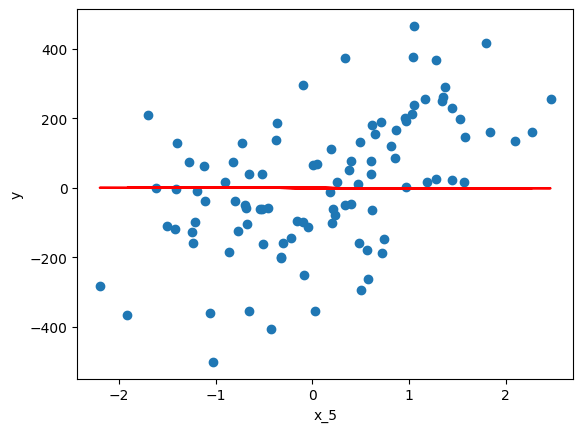

In [7]:
y_hat = predict(w, x[:, 5], b)

plt.scatter(x[:, 5], y)
plt.plot(x[:, 5], y_hat, color='red')
plt.xlabel("x_5")
plt.ylabel("y")

## Loss function: squared error

```math
L_{w,b}(x) = \frac{1}{2}(\hat{y}-y)^2 = \frac{1}{2}(w*x+b-y)^2
```

1. write a function ``loss_function(y: float, y_hat: float) -> float`` that computes the loss (squared error) between $`y`$ and $`\hat{y}`$

In [8]:
def loss_function(y: float, y_hat: float) -> float:
    """ write a function that computes the squared error between y and y_hat """
    ...
    return 1/2 * (y - y_hat) ** 2

In [9]:
loss_function(y, y_hat)

array([1.25320541e+05, 8.73603943e+04, 2.65465206e+04, 2.04685605e+04,
       1.69318636e+04, 8.12904743e+03, 1.72215607e+04, 2.12193746e+03,
       3.65309359e+02, 4.82489101e+03, 3.15023768e+04, 1.13777075e+03,
       6.68778343e+04, 1.96290306e+04, 2.95743029e+03, 1.08844006e+04,
       1.75034377e+04, 1.20135989e+04, 1.30334188e+04, 3.96306361e+04,
       7.40706842e+03, 6.97739677e+03, 5.09824080e+03, 6.29115922e+03,
       6.76273352e+04, 4.50164681e+03, 7.14902750e+04, 1.31942521e+04,
       1.61068192e+04, 1.05782553e+03, 7.59586545e+03, 3.30627494e+04,
       1.82062285e+03, 6.82020858e+01, 1.08867953e+05, 9.98502193e+00,
       4.81742508e+01, 7.66359941e+02, 1.72902492e+03, 3.30260619e+04,
       1.96321173e+03, 8.57494418e-02, 1.57543886e+02, 1.04832816e+04,
       6.98552775e+04, 1.32521202e+04, 1.62526360e+04, 6.26771988e+04,
       1.46112614e+02, 4.85734274e+03, 7.99604199e+02, 2.01784137e+04,
       1.09405632e+04, 6.49578933e+04, 7.48367889e+02, 1.83136997e+03,
      

## Cost function: mean squared error

```math
J_{w,b} = \frac{1}{m} \underset{i=1}{\overset{m}{\sum}} L_{w,b}(x) = \frac{1}{2m} \underset{i=1}{\overset{m}{\sum}} (\hat{y}-y)^2
```

1. Write a function `cost_function(y: np.ndarray, y_hat: np.ndarray) -> float` that computes the cost (mean squared error) for a given set of parameters between $`y`$ and $`\hat{y}`$
2. plot the cost function for a large range of $`w`$ values

In [10]:
def cost_function(y: np.ndarray, y_hat: np.ndarray) -> float:
    """ write a function that computes the mean squared error between y and y_hat """
    ...
    return sum(loss_function(y, y_hat)) / len(y)

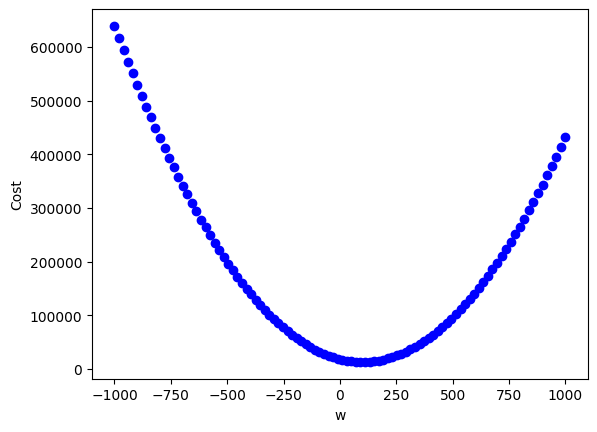

In [12]:
w_range = np.linspace(-1000, 1000, 100)
for w in w_range:
    y_hat = predict(w, x[:, 5], b)
    cost = cost_function(y, y_hat)
    plt.scatter(w, cost, color='blue')
plt.xlabel("w")
plt.ylabel("Cost")
plt.show()

## Objective

Find values of parameters $`w^\star`$ and $`b^\star`$ so that $`J_{\hat{w},\hat{b}}`$ is as low as possible:

```math
w^\star,b^\star=\underset{w,b}{\argmin} \frac{1}{2m} \underset{i=1}{\overset{m}{\sum}} (\hat{y}-y)^2

```

## Gradient Descent Algorithm


Algorithm:

For $`i \in [1..n]`$, repeat:
```math
w := w - \alpha \frac{\partial J}{\partial w}
```
```math
b := b - \alpha \frac{\partial J}{\partial b}
```
The gradient descent algorithm is repeated for a certain number of $`n`$ iterations. $`\alpha > 0`$ is the learning rate of the gradient descent, corresponding to how much you update the parameter's values at each iteration.

Intuition: For a convex cost function, Gradient Descent tells you in which direction to look for values of parameters.

Example:
* Let's take $`w^\star \ll w`$. The slope of the cost function at $`w`$ is positive, hence $`\frac{\partial J}{\partial w} > 0`$. Therefore in this state, $`- \alpha \frac{\partial J}{\partial w} < 0`$, will decrease the value of $`w`$.
* Let's take $`w \ll w^\star`$. The slope of the cost function at $`w`$ is negative, hence $`\frac{\partial J}{\partial w} < 0`$. Therefore in this state, $`- \alpha \frac{\partial J}{\partial w} > 0`$, will increase the value of $`w`$.


Gradient formulas:
```math
\frac{\partial J}{\partial w} = \frac{1}{m} \underset{i=1}{\overset{m}{\sum}} (\hat{y}-y)x
```
```math
\frac{\partial J}{\partial b} = \frac{1}{m} \underset{i=1}{\overset{m}{\sum}} (\hat{y}-y)
```

1. write a function `compute_gradient(y: np.ndarray, y_hat: np.ndarray, x: np.ndarray) -> tuple[float, float]` that computes the gradient of the squared error loss with respect to parameters $`w`$ and $`b`$
2. write a function `update_parameters(w: float, b: float, dj_dw: float, dj_db: float, learning_rate: float) -> tuple[float, float]` that updates the parameters $`w`$ and $`b`$ using the gradients of the cost function $`\frac{\partial J}{\partial w}`$ and $`\frac{\partial J}{\partial b}`$ and the learning rate  $`\alpha`$
3. write a function `gradient_descent_one_step(x: np.ndarray, y: np.ndarray, w: float, b: float, learning_rate: float) -> tuple[float, float]` that leverages methods, `predict`, `compute_gradient`, and `update_parameters`, that outputs updated parameters $`w`$ and $`b`$ for one step of gradient descent
4. write a function ``gradient_descent(x: np.ndarray, y: np.ndarray, learning_rate: float, n_iterations: int) -> tuple[float, float]`` that does $`n`$ iterations of gradient descent. Initialize values of parameters $`w`$ and $`b`$ randomly. Make sure to print/plot updated Cost per iteration (learning curve)
5. apply gradient descent for a sufficient $`n`$ iterations and plot the predicted values

In [58]:
def compute_gradient(y: np.ndarray, y_hat: np.ndarray, x: np.ndarray) -> tuple[float, float]:
    """ write a function that computes the gradient of the squared error loss with respect to w and b """
    dw = ((y_hat - y) * x).mean()
    db = (y_hat - y).mean()
    return dw, db

def update_parameters(w: float, b: float, dj_dw: float, dj_db: float, learning_rate: float) -> tuple[float, float]:
    """ write a function that updates the parameters w and b using the gradients dw and db and the learning rate """
    w = w - learning_rate * dj_dw
    b = b - learning_rate * dj_db
    return w, b

def gradient_descent_one_step(x: np.ndarray, y: np.ndarray, w: float, b: float, learning_rate: float) -> tuple[float, float]:
    """ write a function that performs one step of gradient descent to optimize w and b """
    y_hat = predict(w, x, b)
    dw, db = compute_gradient(y, y_hat, x)
    w, b = update_parameters(w, b, dw, db, learning_rate)
    return w, b

def gradient_descent(x: np.ndarray, y: np.ndarray, learning_rate: float, n_iterations: int) -> tuple[float, float]:
    """ write a function that performs gradient descent to optimize w and b """
    w, b = init_parameters()

    # iterating gradient descent
    for i in range(n_iterations):
        
        # doing a single step of gradient descent
        w, b = gradient_descent_one_step(x, y, w, b, learning_rate)

        # computing cost for convergence check
        y_hat = predict(w, x, b)
        current_cost = cost_function(y, y_hat)
        
        # printing cost every 25 iterations
        if i % 25 == 0:
            print(f"Iteration {i+1}/{n_iterations}, Cost: {current_cost}")
            plt.scatter(i+1, current_cost, color='blue')

    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title("Learning Curve")
    plt.show()

    return w, b


Iteration 1/1000, Cost: 18220.731944517935
Iteration 26/1000, Cost: 17962.066637964846
Iteration 51/1000, Cost: 17716.73707121988
Iteration 76/1000, Cost: 17484.049557311508
Iteration 101/1000, Cost: 17263.346783186833
Iteration 126/1000, Cost: 17054.00588883936
Iteration 151/1000, Cost: 16855.436648506766
Iteration 176/1000, Cost: 16667.0797484857
Iteration 201/1000, Cost: 16488.405156403478
Iteration 226/1000, Cost: 16318.910577063518
Iteration 251/1000, Cost: 16158.119990243054
Iteration 276/1000, Cost: 16005.582266069825
Iteration 301/1000, Cost: 15860.86985383853
Iteration 326/1000, Cost: 15723.577540350161
Iteration 351/1000, Cost: 15593.321274066899
Iteration 376/1000, Cost: 15469.73705157413
Iteration 401/1000, Cost: 15352.479863028897
Iteration 426/1000, Cost: 15241.222693452157
Iteration 451/1000, Cost: 15135.655576890242
Iteration 476/1000, Cost: 15035.484700630379
Iteration 501/1000, Cost: 14940.431556805685
Iteration 526/1000, Cost: 14850.232138867508
Iteration 551/1000, C

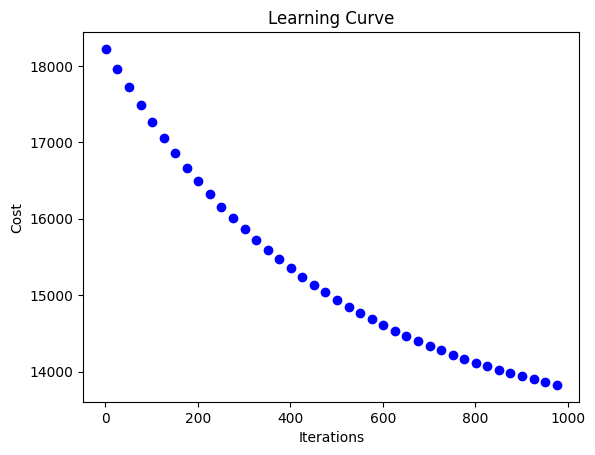

In [ ]:
w_star, b_star = gradient_descent(x[:, 5], y, learning_rate=0.001, n_iterations=1000)

Text(0, 0.5, 'y')

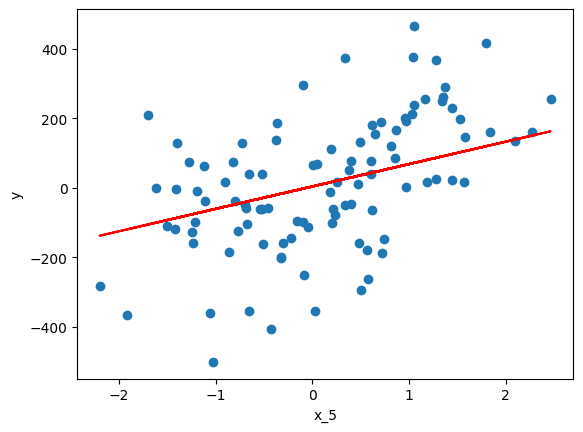

In [ ]:

y_hat = predict(w_star, x[:, 5], b_star)

plt.scatter(x[:, 5], y)
plt.plot(x[:, 5], y_hat, color='red')
plt.xlabel("x_5")
plt.ylabel("y")

# Multivariate regression

```math
\hat{y} = w.x^T+b
```
1. write a function `predict(w: np.ndarray, x: np.ndarray, b: float) -> np.ndarray` that estimates target $`y`$ given features $`x`$ and parameters $`w`$ and $`b`$ in the case of multivariate linear regression
2. write a function `init_parameters(m: int) -> tuple[np.ndarray, float]` that returns random values for parameters $`w`$ and $`b`$, given the number of observations $`m`$
3. apply the model for all the features $`x`$ (compute $`\hat{y}`$)

In [36]:
def predict(w: np.ndarray, x: np.ndarray, b: float) -> np.ndarray:
    """ write a function that predicts y given x, w and b in the case of multivariate linear regression"""
    return np.dot(w, x.T) + b


def init_parameters() -> tuple[np.ndarray, float]:
    """ write a function that initializes w and b to random values """
    ...
    return np.random.randn(x.shape[1]), np.random.randn()

w, b = init_parameters()
w, b

(array([-1.21601377,  1.48738759, -0.22559056,  0.46936277,  1.36836324,
         1.88081745,  1.83740834, -1.25938394,  1.15030406,  0.34866763]),
 -0.16289503981330097)

## Feature Scaling / Normalization

Intuition: gradient descent won't work as well for features $`x`$ with wildly different scales. With different scales, each parameter $`w_i`$, corresponding to feature $`x_i`$ needs to be updated with a different scale. To prevent this, features are scaled to comparable ranges.

Mean Normalization:

```math
x_i = \frac{x_i - \mu_i}{\max{x_i} - \min{x_i}}
```

Z-score Normalization:

```math
x_i = \frac{x_i - \mu_i}{\sigma_i}
```

where $`\mu_i `$ is the mean of $`x_i`$ and $` \sigma_i`$ is its standard deviation

1. Apply normalization to your dataset of features $`x`$

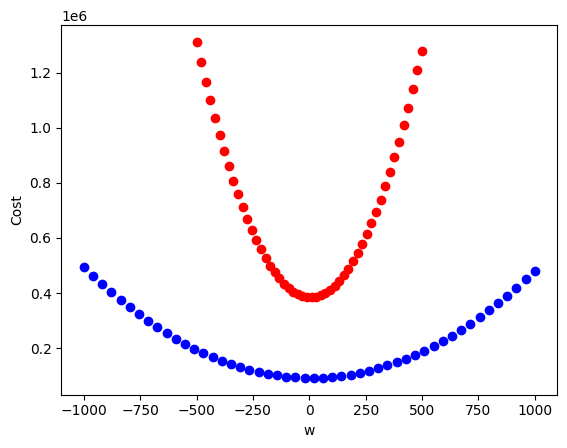

In [45]:
for w_0 in np.linspace(-1000, 1000, 50):
    w[0] = w_0
    y_hat = predict(w, x, b)
    cost = cost_function(y, y_hat)
    plt.scatter(w_0, cost, color='blue')
x[:, 1] *= 3
for w_1 in np.linspace(-500, 500, 50):
    w[1] = w_1
    y_hat = predict(w, x, b)
    cost = cost_function(y, y_hat)
    plt.scatter(w_1, cost, color='red')
x[:, 1] /= 3

plt.xlabel("w")
plt.ylabel("Cost")
plt.show()

In [52]:
mu = x.mean(axis=0)
std = x.std(axis=0)
x = (x - mu) / std

In [54]:
y_hat = predict(w, x, b)

In [55]:
cost_function(y, y_hat)

np.float64(607265.0827771389)

## Gradient Descent Step


```math
w := w - \alpha \frac{\partial J}{\partial w}
```
```math
b := b - \alpha \frac{\partial J}{\partial b}
```

```math
\frac{\partial J}{\partial w} = \frac{1}{m} \sum{x^T.(\hat{y}-y)}
```
```math
\frac{\partial J}{\partial b} = \frac{1}{m} \sum{(\hat{y}-y)}
```
1. update the `compute_gradient(y: np.ndarray, y_hat: np.ndarray, x: np.ndarray) -> tuple[np.ndarray, float]` for the multivariate linear regression

In [59]:
def compute_gradient(y: np.ndarray, y_hat: np.ndarray, x: np.ndarray) -> tuple[np.ndarray, float]:
    """ write a function that computes the gradient of the squared error loss with respect to w and b """
    ...
    dw = np.dot(x.T, (y_hat - y)) / len(y)
    db = np.sum(y_hat - y) / len(y)
    return dw, db

compute_gradient(y, y_hat, x)

(array([ 995.12617559,  494.91490874,  -24.62118689,  -12.86589717,
          74.72746634, -150.43221419,  -96.53984068,  -44.94054467,
           1.27432054,   41.13461138]),
 np.float64(-11.29588225278503))

Iteration 1/200, Cost: 13992.958035274216
Iteration 26/200, Cost: 105.40517032554817
Iteration 51/200, Cost: 6.022895758620809
Iteration 76/200, Cost: 0.914546250128903
Iteration 101/200, Cost: 0.5021038035354919
Iteration 126/200, Cost: 0.4664736825017707
Iteration 151/200, Cost: 0.46336094419418344
Iteration 176/200, Cost: 0.4630883454339994


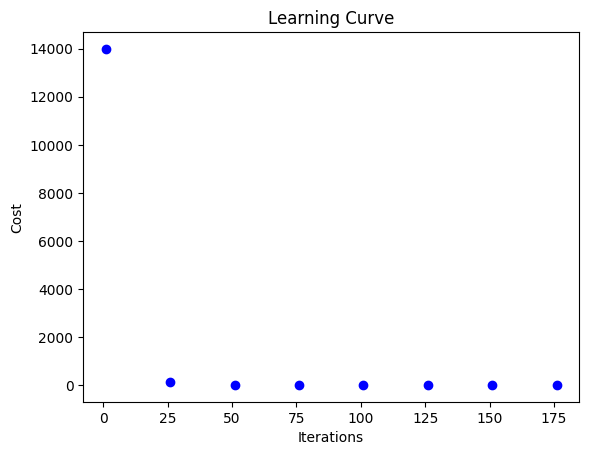

(array([15.0538773 , 48.80765976,  4.81342509, 64.92481146, 90.9607415 ,
        71.38763663, 88.46177394, 10.7540848 ,  3.33442008, 65.02081794]),
 np.float64(11.132987205333862))

In [61]:
gradient_descent(x, y, learning_rate=0.1, n_iterations=200)

# Regularized Gradient Descent 
## Cost function

```math
J_{w,b} = \frac{1}{2m}\sum{L_{w,b}(x)} + \frac{\lambda_2}{2} \sum{w^2}
```